# Computer Exercise 13.3 — Problem 1

## 등식 제약 최적화: 이차 벌점법(Quadratic Penalty)과 라그랑주 승수

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 13.3 Constrained Optimization — *Penalty & Augmented Lagrangian*
> **풀이 일자**: Day 48
> **언어**: Python 3 (NumPy / SciPy / pandas / matplotlib)

## 1. 문제 (원문)

> **1.** Consider the equality-constrained problem
> $$\min_{\mathbf{x}\in\mathbb{R}^n} f(\mathbf{x})\quad\text{subject to}\quad c_i(\mathbf{x})=0,\ i=1,\dots,m.$$
> Implement the **quadratic penalty method**: for an increasing sequence of penalty
> parameters $\mu_k\to\infty$, minimize the unconstrained surrogate
> $Q(\mathbf{x};\mu)=f(\mathbf{x})+\tfrac{\mu}{2}\sum_i c_i(\mathbf{x})^2$.
> Test on $\min\,x_1+x_2$ s.t. $x_1^2+x_2^2-2=0$. Report the iterates, the
> constraint violation, the recovered Lagrange-multiplier estimate, and the
> conditioning of the penalty Hessian as $\mu$ grows. Compare with the
> **augmented Lagrangian** method.

### 한국어 풀이용 정리
등식 제약 $c(\mathbf{x})=0$ 아래에서 $f$ 를 최소화한다. 제약을 직접 다루는 대신,
**제약 위반을 제곱해 벌점**으로 목적함수에 더한 $Q(\mathbf{x};\mu)$ 를 무제약 최소화한다.
$\mu$ 를 키울수록 해가 제약면으로 다가가지만 **헤시안 조건수가 $\mu$ 에 비례해 폭발**한다.
이 부작용을 **증강 라그랑지안(augmented Lagrangian)** 이 어떻게 완화하는지 비교한다.

테스트 문제는 Nocedal–Wright의 고전 예제로 해석해가 알려져 있다:
$$\mathbf{x}^\star=(-1,-1),\quad f^\star=-2,\quad \lambda^\star=-\tfrac12.$$

## 2. 수학적 배경

### 2.1 라그랑주 승수와 1차 최적성(KKT)
라그랑지안 $\mathcal{L}(\mathbf{x},\boldsymbol{\lambda})=f(\mathbf{x})-\sum_i\lambda_i c_i(\mathbf{x})$ 의
정상점은
$$\nabla f(\mathbf{x}^\star)=\sum_i \lambda_i^\star\,\nabla c_i(\mathbf{x}^\star),\qquad c_i(\mathbf{x}^\star)=0.$$
즉 목적함수의 기울기가 제약 기울기들의 선형결합이어야 한다.

### 2.2 이차 벌점함수
$$\boxed{\,Q(\mathbf{x};\mu)=f(\mathbf{x})+\frac{\mu}{2}\sum_{i=1}^m c_i(\mathbf{x})^2\,}$$
$Q$ 의 정상조건 $\nabla Q=\nabla f+\mu\sum_i c_i\,\nabla c_i=0$ 를 KKT와 비교하면
$$\lambda_i^\star \approx -\mu\,c_i(\mathbf{x}_\mu).$$

### 2.3 ill-conditioning
$$\nabla^2 Q = \nabla^2 f + \mu\sum_i\big(\nabla c_i\nabla c_i^{\top}+c_i\nabla^2 c_i\big).$$
제약면에 수직인 방향의 곡률은 $\mathcal{O}(\mu)$, 접선 방향은 $\mathcal{O}(1)$ 이라
조건수 $\kappa(\nabla^2 Q)=\mathcal{O}(\mu)$ 로 커진다.

### 2.4 증강 라그랑지안
$$\mathcal{L}_A(\mathbf{x},\boldsymbol{\lambda};\mu)=f(\mathbf{x})-\sum_i\lambda_i c_i(\mathbf{x})+\frac{\mu}{2}\sum_i c_i(\mathbf{x})^2,$$
승수 갱신 $\lambda_i\leftarrow\lambda_i-\mu\,c_i(\mathbf{x})$ 를 곁들이면 **$\mu\to\infty$ 없이** 제약을 만족시켜 조건수 폭발을 피한다.

## 3. 풀이 흐름

1. 목적함수 $f=x_1+x_2$, 제약 $c=x_1^2+x_2^2-2$ 와 기울기를 정의.
2. 벌점함수 $Q(\mathbf{x};\mu)$ 를 구성, 각 $\mu_k\in\{1,\dots,10^7\}$ 에서 BFGS로 최소화 (warm start).
3. 각 단계의 해, $f$, **제약 위반** $|c|$, 승수 추정 $-\mu c$, 헤시안 조건수를 기록.
4. 표로 $|c|\sim 1/\mu$, $\kappa\sim\mu$ 확인.
5. 동일 문제를 **증강 라그랑지안**으로 풀어 적당한 $\mu$ 에서 제약이 기계정밀도까지 만족되는지 확인.
6. 두 방법의 제약위반 곡선 비교 시각화.

In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda v: f'{v:.4e}')

# ----- min x1+x2  s.t.  c(x)=x1^2+x2^2-2=0 -----
def f(x):      return x[0] + x[1]
def grad_f(x): return np.array([1.0, 1.0])
def c(x):      return x[0]**2 + x[1]**2 - 2.0
def grad_c(x): return np.array([2*x[0], 2*x[1]])

x_star, f_star, lam_star = np.array([-1.0,-1.0]), -2.0, -0.5
print(f"해석해 x* = {x_star},  f* = {f_star},  lambda* = {lam_star}")

def Q(x, mu):      return f(x) + 0.5*mu*c(x)**2
def grad_Q(x, mu): return grad_f(x) + mu*c(x)*grad_c(x)
def hess_Q(x, mu):
    gc = grad_c(x)
    return mu*(np.outer(gc, gc) + c(x)*2*np.eye(2))

해석해 x* = [-1. -1.],  f* = -2.0,  lambda* = -0.5


In [2]:
# ----- 벌점 파라미터를 키우며 순차 최소화 (warm start) -----
mus = [10.0**k for k in range(0, 8)]
x   = np.array([-0.5, -0.5]); rows = []
for mu in mus:
    res = minimize(Q, x, args=(mu,), jac=grad_Q, method='BFGS',
                   options={'gtol': 1e-12, 'maxiter': 500})
    x = res.x
    rows.append({'mu': mu, 'x1': x[0], 'x2': x[1], 'f': f(x),
                 '|c|': abs(c(x)), 'lambda_est': -mu*c(x),
                 'err_x': np.linalg.norm(x - x_star),
                 'cond(H)': np.linalg.cond(hess_Q(x, mu))})
df = pd.DataFrame(rows); df

,mu,x1,x2,f,|c|,lambda_est,err_x,cond(H)
0,1.0000e+00,-1.1072e+00,-1.1072e+00,-2.2143e+00,4.5161e-01,-4.5161e-01,1.5155e-01,1.1857e+01
1,1.0000e+01,-1.0123e+00,-1.0123e+00,-2.0245e+00,4.9394e-02,-4.9394e-01,1.7357e-02,8.3982e+01
2,1.0000e+02,-1.0012e+00,-1.0012e+00,-2.0025e+00,4.9938e-03,-4.9938e-01,1.7645e-03,8.0400e+02
3,1.0000e+03,-1.0001e+00,-1.0001e+00,-2.0002e+00,4.9994e-04,-4.9994e-01,1.7674e-04,8.0040e+03
4,1.0000e+04,-1.0000e+00,-1.0000e+00,-2.0000e+00,4.9999e-05,-4.9999e-01,1.7677e-05,8.0004e+04
5,1.0000e+05,-1.0000e+00,-1.0000e+00,-2.0000e+00,5.0000e-06,-5.0000e-01,1.7678e-06,8.0000e+05
6,1.0000e+06,-1.0000e+00,-1.0000e+00,-2.0000e+00,5.0000e-07,-5.0000e-01,1.7678e-07,8.0000e+06
7,1.0000e+07,-1.0000e+00,-1.0000e+00,-2.0000e+00,5.0000e-08,-5.0000e-01,1.7678e-08,8.0000e+07


In [3]:
# ----- 증강 라그랑지안 -----
def aug_min(mu0=10.0, outer=8):
    x = np.array([-0.5,-0.5]); lam = 0.0; mu = mu0; hist=[]
    for k in range(outer):
        LA     = lambda z: f(z) - lam*c(z) + 0.5*mu*c(z)**2
        gradLA = lambda z: grad_f(z) + (-lam + mu*c(z))*grad_c(z)
        x = minimize(LA, x, jac=gradLA, method='BFGS',
                     options={'gtol':1e-12,'maxiter':500}).x
        lam = lam - mu*c(x)
        hist.append({'outer':k+1,'mu':mu,'|c|':abs(c(x)),
                     'lambda':lam,'err_x':np.linalg.norm(x-x_star)})
        if abs(c(x)) > 1e-12: mu *= 5.0
    return pd.DataFrame(hist)
df_AL = aug_min(); df_AL

,outer,mu,|c|,lambda,err_x
0,1,1.0000e+01,4.9394e-02,-4.9394e-01,1.7357e-02
1,2,5.0000e+01,1.2094e-04,-4.9998e-01,4.2758e-05
2,3,2.5000e+02,6.0438e-08,-5.0000e-01,2.1368e-08
3,4,1.2500e+03,6.0432e-12,-5.0000e-01,2.1366e-12
4,5,6.2500e+03,0.0000e+00,-5.0000e-01,0.0000e+00
5,6,6.2500e+03,0.0000e+00,-5.0000e-01,0.0000e+00
6,7,6.2500e+03,0.0000e+00,-5.0000e-01,0.0000e+00
7,8,6.2500e+03,0.0000e+00,-5.0000e-01,0.0000e+00


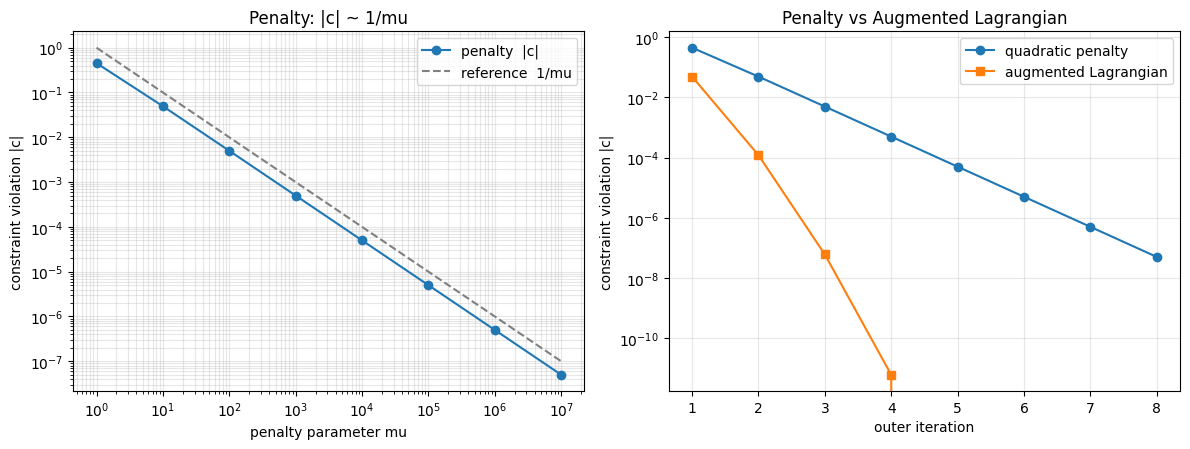

penalty 최종: |c|=5.000e-08, cond(H)=8.000e+07
aug-Lag 최종: |c|=0.000e+00, lambda=-0.500000 (참값 -0.5)


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
ax[0].loglog(df['mu'], df['|c|'], 'o-', label='penalty  |c|')
ax[0].loglog(df['mu'], 1.0/df['mu'], '--', color='gray', label='reference  1/mu')
ax[0].set_xlabel('penalty parameter mu'); ax[0].set_ylabel('constraint violation |c|')
ax[0].set_title('Penalty: |c| ~ 1/mu'); ax[0].legend(); ax[0].grid(True, which='both', alpha=.3)
ax[1].semilogy(np.arange(1,len(df)+1), df['|c|'], 'o-', label='quadratic penalty')
ax[1].semilogy(df_AL['outer'], df_AL['|c|'], 's-', label='augmented Lagrangian')
ax[1].set_xlabel('outer iteration'); ax[1].set_ylabel('constraint violation |c|')
ax[1].set_title('Penalty vs Augmented Lagrangian'); ax[1].legend(); ax[1].grid(True, which='both', alpha=.3)
plt.tight_layout(); plt.show()
print(f"penalty 최종: |c|={df['|c|'].iloc[-1]:.3e}, cond(H)={df['cond(H)'].iloc[-1]:.3e}")
print(f"aug-Lag 최종: |c|={df_AL['|c|'].iloc[-1]:.3e}, lambda={df_AL['lambda'].iloc[-1]:.6f} (참값 -0.5)")

## 4. 결과 해석

1. **수렴 방향**: 벌점해 $\mathbf{x}_\mu$ 는 $\mu$ 증가에 따라 해석해 $(-1,-1)$ 로 다가가고 $f\to-2$.
2. **제약 위반 $\sim 1/\mu$**: 왼쪽 로그-로그에서 $|c|$ 가 기준선 $1/\mu$ 와 평행 — 제약위반이 $\mathcal{O}(1/\mu)$ 로만 줄어 정확히 맞추려면 $\mu$ 를 크게 해야 한다.
3. **승수 추정 $-\mu c$**: `lambda_est` 가 $-0.5$ 로 수렴 — 잔여 위반에서 라그랑주 승수를 복원.
4. **조건수 폭발**: `cond(H)` 가 $\mu$ 에 비례. $\mu\sim10^7$ 에서 반올림오차가 정확도를 갉아먹는 순수 벌점법의 한계.
5. **증강 라그랑지안의 우위**: 오른쪽에서 AL은 적당한 $\mu$ 로도 제약위반을 기계정밀도까지 떨어뜨린다. 승수 갱신이 $\mu\to\infty$ 를 대체.

> **결론**: 순수 벌점법은 정확도와 조건수가 trade-off다. 증강 라그랑지안은 승수를 명시적으로 갱신해 작은 $\mu$ 로도 같은 정확도를 얻는다.

**다음 문제로의 연결**: 등식 제약을 벌점으로 다뤘으니, CE 2에서는 **부등식 제약**을 로그-장벽 내부점법으로 다루며 *중심 경로(central path)* 를 추적한다.